# 📝 Proyecto: Clasificador de Vinos con KNN
Entrenaremos un modelo de **K-Nearest Neighbors (KNN)** para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

### 📊 Dataset
Utilizaremos el dataset de vinos tintos de la UCI:
[Wine Quality Data Set](https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv)

**Descripción de columnas:**
* **Composición química:** `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`.
* **Objetivo (label):** 
    * `0`: Baja calidad
    * `1`: Calidad media
    * `2`: Alta calidad

In [868]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint

In [869]:
# Cargamos el dataset de vinos
df=pd.read_csv("../data/raw/winequality-red.csv", delimiter = ";")
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [870]:
#chekamos la info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [871]:
#Obtenemos que columnas tienen valores unicos aunque todas nuestras variables son numericas quizas sea bueno saber que si hay alguna que intente comportarse como una categorica.
print("------------------PORCENTAJE DE VALORES UNICOS DEL df---------------------\n")
info_uniques = pd.DataFrame({
    'Valores Únicos': df.nunique(),
    'Total Filas': len(df),
    '% Unicidad': (df.nunique() / len(df)) * 100
}).sort_values(by = '% Unicidad', ascending = False)
info_uniques

------------------PORCENTAJE DE VALORES UNICOS DEL df---------------------



,Valores Únicos,Total Filas,% Unicidad
density,436,1599,27.267042
chlorides,153,1599,9.568480
total sulfur dioxide,144,1599,9.005629
volatile acidity,143,1599,8.943089
fixed acidity,96,1599,6.003752
sulphates,96,1599,6.003752
residual sugar,91,1599,5.691057
pH,89,1599,5.565979
citric acid,80,1599,5.003127
alcohol,65,1599,4.065041


In [872]:
# Hacemos un describe para ojear si hay outliers
df.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [873]:
# Vemos que tan desbalanceada esta nuestro target
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

## Analisis Hasta Ahora:
* Tenemos un dataframe de datos de reviews con 1599 filas y 12 columnas.
* 12 Columnas son float y 1 INT.
* `quality` es nustro target que son valores desde el 3 al 8, hara falta hacer una conversion para que sean calidad baja,media y alta.
* Podemos ver que algunas variables tiene outliers por ejemplo `total sulfur dioxide` tiene una desviacion estandar de 32, una media de 46 y un valor maximo de 289, algo parecido pasa con otras como el `pH`, puede ser que los ouliers nos ayuden o no en los resultados del modelo eso lo veremos.

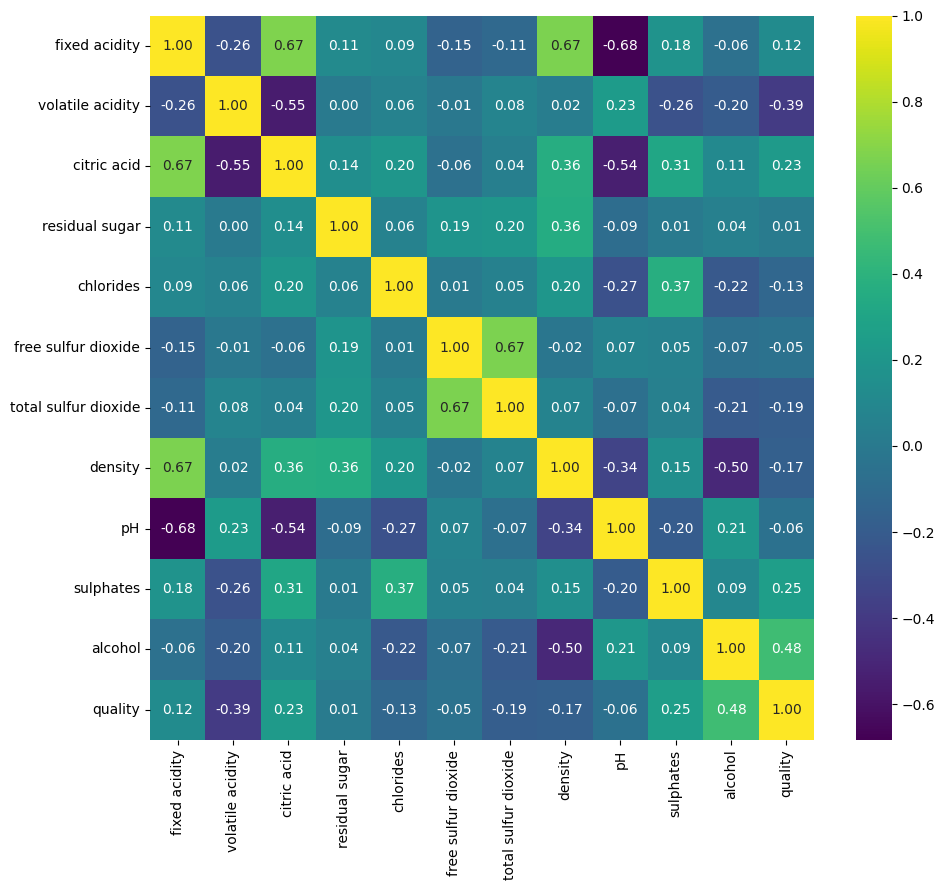

In [874]:
#Vamos a dibujar un heatmap para ver correlaciones ya que todas nuestras variables son numericas.
cols_num = df.select_dtypes(include = ['number']).columns
fig, ax = plt.subplots(figsize = (10,  9))
sns.heatmap(df[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis", ax = ax)
plt.tight_layout()
plt.show()

## Analisis del heatmap
* Con respecto a nuestro target el MVP es la variable `alcohol` con un 0.48 vamos a intentar hacer un filtrado rapido, desde 0.17 hasta 0.48, sino probaremos con un rango mas estricto dado de knn no se suele llevar bien con muchas columnas.


In [875]:
#Hacemos el filtrado rapido con "between"
correlaciones = df.corr()['quality'].sort_values(ascending = False)
# correlaciones = correlaciones[correlaciones.abs().between(0.17, 0.49)] # Comentado porque el rango 0.17-0.49 no arrojaba buenos resultados
correlaciones = correlaciones[correlaciones.abs().between(0.22, 0.49)]
df_corr = pd.concat([df[correlaciones.index], df['quality']], axis = 1)
df_corr

,alcohol,sulphates,citric acid,volatile acidity,quality
0,9.4,0.56,0.00,0.700,5
1,9.8,0.68,0.00,0.880,5
2,9.8,0.65,0.04,0.760,5
3,9.8,0.58,0.56,0.280,6
4,9.4,0.56,0.00,0.700,5
...,...,...,...,...,...
1594,10.5,0.58,0.08,0.600,5
1595,11.2,0.76,0.10,0.550,6
1596,11.0,0.75,0.13,0.510,6
1597,10.2,0.71,0.12,0.645,5


In [876]:
#Separamos nuestro dataframe en X e y
X = df_corr.drop('quality',axis = 1)
y = df_corr['quality']
X.head()

,alcohol,sulphates,citric acid,volatile acidity
0,9.4,0.56,0.00,0.70
1,9.8,0.68,0.00,0.88
2,9.8,0.65,0.04,0.76
3,9.8,0.58,0.56,0.28
4,9.4,0.56,0.00,0.70


In [877]:
# no nos olvidemos que nos piden una prediccion entre 3 opciones calidad baja, media y alta por lo que vamos a intentar agruparlos inteligentemente para tener un support decente
# en las tres categorias. 
# Apartir de ahora voy a trabajar con 2 tipos de agrupaciones porque creo que es importante para el analisis final, uno donde la clase baja(0) incluye elementos de 3 a 5 y otro de 3 a 4
# Hago esto para justificar la desicion de elegir la primera distribucion haciendo la comparativa en una matriz de confucion mas adelante.
# Usare "_alt" para referirme a esta distribucion cada vez que se vea _alt es solo el mismo codigo pero con la otra distribucion.
aux = y.copy()
y = pd.cut(aux, bins=[0, 5, 6, 10], labels=[0, 1, 2])
y_alt = pd.cut(aux, bins=[0, 4, 6, 10], labels=[0, 1, 2])
y.value_counts()
# Por cierto hacemos esto despues del heatmap porque para el mismo nos viene mejor los datos originales (calidad 3, 4, 5, 6, 7, 8), ya que agrupando perdemos sensibilidad.

quality
0    744
1    638
2    217
Name: count, dtype: int64

In [878]:
#Dividimos en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
#Ejemplo de lo que dije antes "_alt" es exactamente lo mismo que arriba pero usando otra distribucion.
X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(X, y_alt, test_size = 0.20, random_state = 42)

In [879]:
#Segun lo que vimos en clases a diferencia de random forest aqui si es mucho muy importante scalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [880]:
#Hacemos una primera prueba del modelo KNeighborsClassifier con n_neighbors = 5
model_knn = KNeighborsClassifier(n_neighbors = 5)
model_knn.fit(X_train_scaled, y_train)
predict_knn = model_knn.predict(X_test_scaled)
metrics_knn = classification_report(y_test, predict_knn, output_dict = True)
print(classification_report(y_test, predict_knn))

              precision    recall  f1-score   support

           0       0.62      0.78      0.69       141
           1       0.54      0.44      0.49       132
           2       0.57      0.43      0.49        47

    accuracy                           0.59       320
   macro avg       0.58      0.55      0.55       320
weighted avg       0.58      0.59      0.58       320



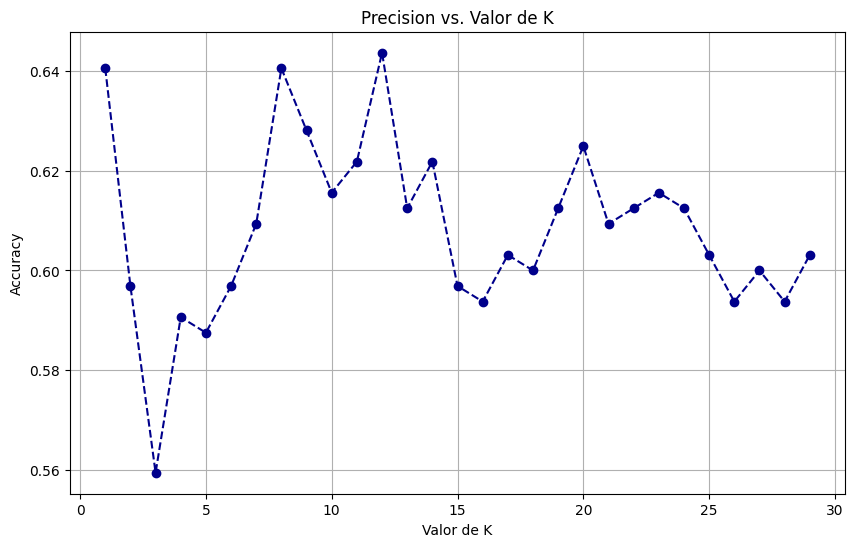

In [881]:
#Tenemos un rendimiento general de 0.59, vamos a dibujar un "brazo" para ver si vemos un "codo".
accuracies = []
# Probamos K's del 1 al 30 y lo metemos en un bucle
k_range = range(1, 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))


plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='darkblue')
plt.title('Precision vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


# Analisis del grafico:
Se logra apreciar un brazo(un poco fracturado), el "quiebre" mas agresivo es cuando k=3 pero su accuracy es muy bajo, en cambio 21 no es el que tiene mejor Accuracy pero es el mas estable porque despues de su "quiebre" no hay tanta "montaña rusa" por asi decirlo, vamos a ver si podemos hacer unos ajustes para mejorar el modelo:
* Primero probemos con un valor de k en 21.
* Luego vamos a buscar con un RamdonGridSearch y GridSearch para encontrar los mejores parametros.

In [882]:
#Hacemos una primera prueba del modelo KNeighborsClassifier con n_neighbors = 21
model_knn = KNeighborsClassifier(n_neighbors = 21)
model_knn.fit(X_train_scaled, y_train)
predict_knn = model_knn.predict(X_test_scaled)
metrics_knn = classification_report(y_test, predict_knn, output_dict = True)
print(classification_report(y_test, predict_knn))

              precision    recall  f1-score   support

           0       0.69      0.78      0.73       141
           1       0.54      0.55      0.54       132
           2       0.50      0.28      0.36        47

    accuracy                           0.61       320
   macro avg       0.57      0.53      0.54       320
weighted avg       0.60      0.61      0.60       320



### El modelo mejoro un poco de 0.59 a 0.61 
Ahora vamos a hacer algunas cosas: primero declaremos un StratifiedKFold, lo hemos usado antes en ejercicios anteriores con el gridsearch para hacer varios try's de testeos, es util para cuando no tenemos tanto support, pero no solo nos va a servir para los grid search tambien para hacer cross-validation que en palabras sencillas nos sirve para evaluar la robustez de nuestro modelo.

In [883]:
# primero que nada declaremos cual va a ser nuestro scoring objetivo, probe con varios y el que me daba mejores resultados era el que balanceaba el recall es decir "recall_weighted"
scoring = 'recall_weighted'
#Definimos cuantos "try's" va a tener nuestro StratifiedKFold
n_splits = 10
cv = StratifiedKFold(n_splits = n_splits, shuffle=True, random_state=42)
#usamos la funcion cross_val_score pasandole nuestro modelo
scores_knn = cross_val_score(model_knn, X_train_scaled, y_train, cv=cv, scoring = scoring)
print(f"Precision media: {scores_knn.mean():.4f}")
print(f"Desviación estandar (Robustez): {scores_knn.std():.4f}")

Precision media: 0.6239
Desviación estandar (Robustez): 0.0314


In [884]:
# precision de 0.6239 y una robustes de 0.031 no estan mal pero vamos a ver si lo mejoramos buscando mejores parametros
# Tomamos parte del codigo de RandomizedSearchCV y GridSearch del ejercicio pasado para buscar los mejores parametros
folder = '../data/processed/models/k-nearest/'
file = 'model_kn.pkl'
path = folder + file

if not os.path.exists(path):
    if not os.path.exists(folder):
        os.makedirs(folder)
    # Inicializamos el modelo KNN
    base_model = KNeighborsClassifier(n_jobs = -1)

    # Vamos a probar una serie de parametros primero en un rango amplio con el RandomizedSearchCV
    random_params = {
        "n_neighbors": randint(1, 40),
        "weights": ['uniform', 'distance'],         
        "metric": ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
        "p": [1, 2, 3],                           
        "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
        "leaf_size": randint(4, 60)               
    }
    
    random_search = RandomizedSearchCV(
        estimator = base_model,
        param_distributions = random_params,
        n_iter = 400,
        scoring = scoring, 
        cv = cv,
        random_state = 42,
        n_jobs = -1
    )
  
    random_search.fit(X_train_scaled, y_train)
    model_grid = random_search.best_estimator_
   
    print(f"Mejores parametros encontrados: {random_search.best_params_}")
    print(f"Mejor score de precisión: {random_search.best_score_:.4f}")
  

else:
    model_grid = joblib.load(path)
    print("Modelo cargado exitosamente.")

Modelo cargado exitosamente.


In [885]:
# Ahora el GridSearchCV tomando en cuanta lo que obtubimos con el RandomizedSearchCV, lo mismo que con el ejercicio pasado
def range_params(param, steps = 2, step_size = 1, min_val = 1):
    param_list = []
    decimals = max(0, -int(round(np.log10(step_size)))) if step_size < 1 else 0
    
    for i in range(steps, 0, -1):
        val = round(param - i*step_size, decimals)
        if val >= min_val:
            param_list.append(val)
            
    param_list.append(param)
    
    for i in range(1, steps+1):
        param_list.append(round(param + i*step_size, decimals))
        
    return sorted(list(set(param_list)))

if not os.path.exists(path):
    # Extraemos los mejores parametros del paso anterior
    best_params = random_search.best_params_

    # Construimos el grid alrededor de los mejores valores numericos, mantenemos el mejor p encontrado,el mejor peso, la mejor metrica y el mejor algoritmo
    grid_params = {
        "n_neighbors": range_params(best_params["n_neighbors"], steps=5, step_size=5, min_val=1),
        "leaf_size": range_params(best_params["leaf_size"], steps=4, step_size=1, min_val=1),
        "p": range_params(best_params["p"], steps=3, step_size=1, min_val=1), 
        "weights": [best_params["weights"]], 
        "metric": [best_params["metric"]], 
        "algorithm": [best_params["algorithm"]] 
    }

    grid_search = GridSearchCV(
        estimator = base_model,
        param_grid = grid_params,
        scoring = scoring,
        cv = cv,
        n_jobs = -1
    )
    grid_search.fit(X_train_scaled, y_train)
    
    # Guardamos el modelo definitivo
    model_grid = grid_search.best_estimator_
    joblib.dump(model_grid, path)
    
    print(f"Mejor combinación final: {grid_search.best_params_}")
    print(f"Precision final: {grid_search.best_score_:.4f}")
    
    # Aca entremanos la otra distribucion solo con fines de comparar.
    random_search.fit(X_train_scaled, y_train_alt)
    model_grid_alt = random_search.best_estimator_
else:
    model_grid = joblib.load(path)
    print("Modelo cargado desde el disco.")

Modelo cargado desde el disco.


In [886]:
#Imprimimos los resultados
columns = ["n_neighbors" ,"leaf_size" ,"p" ,"weights" ,"metric" ,"algorithm"]
parameters_result = pd.DataFrame([model_grid.get_params()])
parameters_result[columns]

,n_neighbors,leaf_size,p,weights,metric,algorithm
0,32,11,1,distance,manhattan,kd_tree


In [887]:
# Vemos las metricas del nuevo modelo
model_grid.fit(X_train_scaled, y_train)
predict_grid = model_grid.predict(X_test_scaled)
metrics_grid = classification_report(y_test, predict_grid, output_dict = True)
print(classification_report(y_test, predict_grid))
# Metricas de la distribucion alternativa
predict_grid_alt = model_grid_alt.predict(X_test_scaled)
metrics_grid_alt = classification_report(y_test_alt, predict_grid_alt, output_dict = True)

              precision    recall  f1-score   support

           0       0.74      0.84      0.79       141
           1       0.66      0.60      0.63       132
           2       0.65      0.55      0.60        47

    accuracy                           0.70       320
   macro avg       0.68      0.67      0.67       320
weighted avg       0.69      0.70      0.69       320



C:\Users\Andres\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Andres\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Andres\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [888]:
# Mejoramos el Accuracy de un 0.61 a un 0.70
# Ahora como hicimos con el modelo anterior vamos a aplicar el cross_val_score para evaluar la robustez
scores_grid = cross_val_score(model_grid, X_train_scaled, y_train, cv=cv, scoring = scoring)
scores_grid_alt = cross_val_score(model_grid_alt, X_train_scaled, y_train_alt, cv=cv, scoring = scoring)
print(f"Precision media: {scores_grid.mean():.4f}")
print(f"Desviación estándar (Robustez): {scores_grid.std():.4f}")

Precision media: 0.7185
Desviación estándar (Robustez): 0.0206


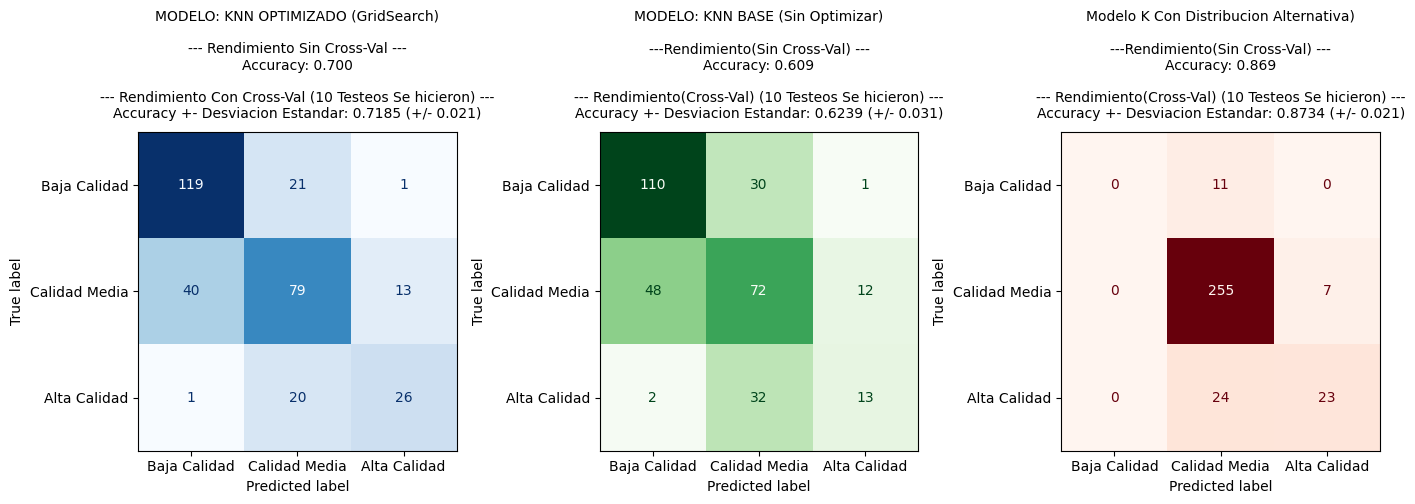

In [889]:
# Vamos ahora a comparar ambas predicciones con una matriz de confusion
nombres_clases = ["Baja Calidad", "Calidad Media", "Alta Calidad"]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))

# --- Modelo K Optimizado(Por GRID) ---
cm_grid = confusion_matrix(y_test, predict_grid)
disp_grid = ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=nombres_clases)
disp_grid.plot(ax=ax1, cmap='Blues', colorbar=False)

# Modificamos un poco el titulo con respecto al ejercicio anterior ya que es importante especificar los valores del cross-validation
ax1.set_title(
    f"MODELO: KNN OPTIMIZADO (GridSearch)\n\n"
    f"--- Rendimiento Sin Cross-Val ---\n"
    f"Accuracy: {metrics_grid['accuracy']:.3f}\n\n"
    f"--- Rendimiento Con Cross-Val ({n_splits} Testeos Se hicieron) ---\n"
    f"Accuracy +- Desviacion Estandar: {scores_grid.mean():.4f} (+/- {scores_grid.std():.3f})", 
    fontsize=10, pad=10
)

# --- Modelo K Base(Sin GRID) ---
cm_knn = confusion_matrix(y_test, predict_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=nombres_clases)
disp_knn.plot(ax=ax2, cmap='Greens', colorbar=False)

ax2.set_title(
    f"MODELO: KNN BASE (Sin Optimizar)\n\n"
    f"---Rendimiento(Sin Cross-Val) ---\n"
    f"Accuracy: {metrics_knn['accuracy']:.3f}\n\n"
    f"--- Rendimiento(Cross-Val) ({n_splits} Testeos Se hicieron) ---\n"
    f"Accuracy +- Desviacion Estandar: {scores_knn.mean():.4f} (+/- {scores_knn.std():.3f})", 
    fontsize=10, pad=10
)
# --- Modelo K Con Distribucion Alternativa ---
cm_alt = confusion_matrix(y_test_alt, predict_grid_alt)
disp_alt = ConfusionMatrixDisplay(confusion_matrix=cm_alt, display_labels=nombres_clases)
disp_alt.plot(ax=ax3, cmap='Reds', colorbar=False)

ax3.set_title(
    f"Modelo K Con Distribucion Alternativa)\n\n"
    f"---Rendimiento(Sin Cross-Val) ---\n"
    f"Accuracy: {metrics_grid_alt['accuracy']:.3f}\n\n"
    f"--- Rendimiento(Cross-Val) ({n_splits} Testeos Se hicieron) ---\n"
    f"Accuracy +- Desviacion Estandar: {scores_grid_alt.mean():.4f} (+/- {scores_grid_alt.std():.3f})", 
    fontsize=10, pad=10
)

plt.tight_layout()
plt.show()

# Analisis De Matriz:
* Podemos observar que el el modelo optimizado predice bien la baja calidad con 119 aciertos, medianamente bien la calidad media 79 aciertos, y regular la alta calidad 26 aciertos, mientras que modelo base predice un poco peor la calidad baja, predice la calida media tambien un poco peor, y la calidad alta la predice mal con solo 13 aciertos y 34 errores.
* Ambos modelos cuando se equivocan no se equivocan de manera garrafal(los errores se concentran en clases adyacentes para decirlo mas bonito), es decir, cuando se predice mal por ejemplo la alta calidad normalmente se predice como media, lo cual no es tan malo como que lo prediga como baja calidad, lo mismo pasa con las otras calidades de vinos.
* El cross validation es mejor en el modelo optimizado que en el base, el acuracy de 0.7185 es el promedio de los 10 testeos de predicciones que se hicieron lo cual es bueno teniendo en cuenta que las predicciones de esta matriz son del 0.70, tambien la desviacion estandar es un 0.021 eso nos dice que nuestro modelo optimizado no vario casi en los 10 testeos, lo que lo hace robusto.
* **IMPORTANTE** explicacion del ultimo modelo, un modelo con esta distribucion bins=[0, 4, 6, 10] queda muy disparejo indentifica casi todo con calidad media, que aunque tiene buena presicion deja con un recall y precision bajisimos a las calidad baja y alta, y aunque se pueda optimizar no mejoraria mucho por lo menos con los metodos que yo intente(oversampling, modificacion de parametros,etc), por eso opte por usar bins=[0, 5, 6, 10] porque aunque algunos vinos bajen a calidad baja, equilibra mucho mas las predicciones, hasta donde tengo entendido un modelo donde alguna de sus clases tenga un recall en 0 y presicion en 0 no es viable aunque sus otras clases tengan un recall y presicion altisimos.

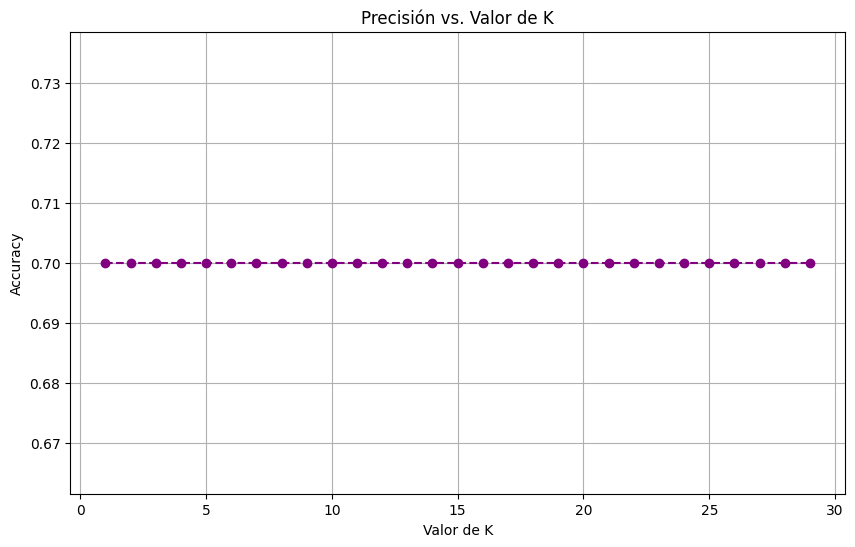

In [890]:
# Si hicimos todo bien el grafico del brazo con el codo ahora deberia ser lineal, indicando estabilidad, vamos a probar
accuracies = []
k_range = range(1, 30)

for k in k_range:
    accuracies.append(model_grid.score(X_test_scaled, y_test))

# Gráfica Visual
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


# Conclusiones finales:
* Como dijimos hicimos tres modelos uno base, otro con grid y otro con una distribucion de clases alternativa, los resultados del grid mejoraron bastante, consiguiendo un rendimiento general del 70% aprox y una media en el rendimiendo del cross-validation del 71.8% haciendo que en ciertos casos nuestro modelo rinda incluso mejor.
* Tambien conseguimos un desviacion estandar del cross-val de 0.021 lo que le da robustez a el modelo.
* Como dije el modelo con una distribucion de clase alternativa arrojo una presicion altisima 87% aprox pero queda muy disparejo indentifica todo con calidad media.

In [891]:
#Guardamos
#Creamos una variable columns_finals que usaremos en la funcion de prueba, la idea es saber la estructura cuando pasemos vinos que tenga la estructura del dataframe original
columns_original = df.drop(columns='quality').columns
columns_model = X_train.columns.tolist()

model_pack = {
    'model_kn': model_grid,
    'model_kn_alt': model_grid_alt,
    'columns_original':columns_original,
    'columns_model':columns_model,
    'nombres_clases': nombres_clases,
    'scaler': scaler,
    'x_train': X_train_scaled,
    'x_test': X_test_scaled,
    'y_train_res': y_train,
    'y_test': y_test
}
path = f"../data/processed/models/k-nearest/"
if not os.path.exists(path):
    os.makedirs(path)
#  Guardamos el paquete
joblib.dump(model_pack, f'{path}models_pack.pkl')

['../data/processed/models/k-nearest/models_pack.pkl']

### Por ultimo probemos el modelo con una funcion "predict_wine_quality"

In [892]:
def predict_wine_quality(data_input, model_path):
    #cargamos todo del paquete que guardamos antes
    pack = joblib.load(model_path)
    model = pack['model_kn']
    model_alt = pack['model_kn_alt']
    columns_model = pack['columns_model']
    columns_original = pack['columns_original']
    scaler = pack['scaler']
    nombres_clases =  pack['nombres_clases']
    # Convertimos el vino de prueba (11 columnas) en un DataFrame temporal
    # para poder filtrar por nombre de columna fácilmente
    input_df = pd.DataFrame([data_input], columns=columns_original)
    
    #  Nos quedamos solo con las columnas que el modelo conoce
    input_filtrado = input_df[columns_model]
    
    # escalamos
    input_escalado = scaler.transform(input_filtrado)
    
    # predecimos
    prediction = model.predict(input_escalado)
    prediction_alt = model_alt.predict(input_escalado)
    
   
    return {
        "modelo_optimizado": nombres_clases[int(prediction[0])],
        "modelo_alternativo": nombres_clases[int(prediction_alt[0])],
    }
  

# en el modulo en 4geeks dice que este vino deveria devolver calidad media.
vino_prueba = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
resultado = predict_wine_quality(vino_prueba, f"{path}models_pack.pkl")
print(f"Resultado modelo optimizado: {resultado['modelo_optimizado']}")
print(f"Resultado modelo alternativo: {resultado['modelo_alternativo']}")

Resultado modelo optimizado: Baja Calidad
Resultado modelo alternativo: Calidad Media


## Analisis Experimento:
* El modelo alternativo si dijo calidad media, pero como dijimos este modelo casi siempre arrojara esto.
* El otro modelo posiblemente considere ese vino con calidad 5 y como nuestra distribucion incluye 5 en calidad baja arroja esto.